In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

In [3]:
data = load_breast_cancer()

X= data.data
y= data.target

In [4]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [7]:
print(data.target_names)
print(data.feature_names)

['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [9]:
print(pd.Series(y).value_counts())

1    357
0    212
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [12]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 2 70]]


                 Actual

              0       1

Predicted 0   TN      FN

Predicted 1   FP      TP


TN = 38

FN = 4

FP = 2

TP = 70

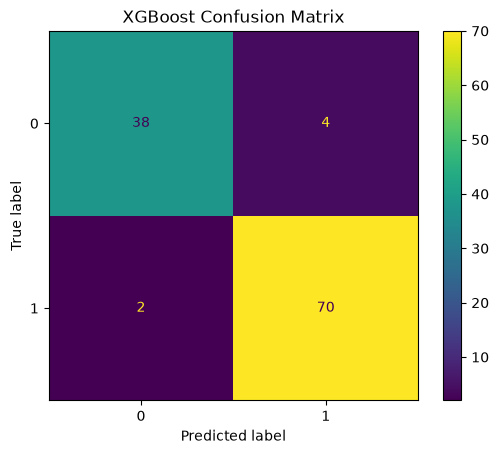

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Precision


When the model predicts positive, how often is it correct?

In [ ]:
precision_score(y_test, y_pred)

Recall


Out of all actual positive cases, how many did the model detect?

In [19]:
recall_score(y_test, y_pred)

0.9722222222222222

F1


Combines precision and recall.

In [18]:
f1_score(y_test, y_pred)

0.958904109589041

Predict Probability

In [20]:
y_prob = model.predict_proba(X_test)

In [21]:
y_prob

array([[9.9855977e-01, 1.4402528e-03],
       [2.1051764e-03, 9.9789482e-01],
       [9.9105382e-01, 8.9461701e-03],
       [7.8520828e-01, 2.1479172e-01],
       [9.9882489e-01, 1.1751133e-03],
       [3.7765503e-03, 9.9622345e-01],
       [7.3510408e-04, 9.9926490e-01],
       [9.9841070e-01, 1.5892886e-03],
       [9.9891424e-01, 1.0857576e-03],
       [9.9885744e-01, 1.1425627e-03],
       [1.8982291e-03, 9.9810177e-01],
       [9.9769360e-01, 2.3064262e-03],
       [1.8278360e-03, 9.9817216e-01],
       [9.9852157e-01, 1.4784335e-03],
       [9.9778771e-01, 2.2122955e-03],
       [6.2747359e-02, 9.3725264e-01],
       [4.2511320e-01, 5.7488680e-01],
       [2.3212194e-02, 9.7678781e-01],
       [4.6333075e-03, 9.9536669e-01],
       [1.4542520e-02, 9.8545748e-01],
       [9.9834871e-01, 1.6512838e-03],
       [8.6067355e-01, 1.3932647e-01],
       [1.4564991e-03, 9.9854350e-01],
       [1.7023683e-03, 9.9829763e-01],
       [3.9464235e-03, 9.9605358e-01],
       [3.0309486e-01, 6.

Probability of Class 1



In [23]:
y_prob1 = model.predict_proba(X_test)[:, 1]
y_prob1

array([1.4402528e-03, 9.9789482e-01, 8.9461701e-03, 2.1479172e-01,
       1.1751133e-03, 9.9622345e-01, 9.9926490e-01, 1.5892886e-03,
       1.0857576e-03, 1.1425627e-03, 9.9810177e-01, 2.3064262e-03,
       9.9817216e-01, 1.4784335e-03, 2.2122955e-03, 9.3725264e-01,
       5.7488680e-01, 9.7678781e-01, 9.9536669e-01, 9.8545748e-01,
       1.6512838e-03, 1.3932647e-01, 9.9854350e-01, 9.9829763e-01,
       9.9605358e-01, 6.9690514e-01, 8.4556604e-04, 9.9676943e-01,
       9.9919659e-01, 9.9545300e-01, 9.9055380e-01, 9.9911052e-01,
       9.9842107e-01, 9.6657348e-01, 1.0213018e-03, 7.7590871e-01,
       9.9627966e-01, 9.0912014e-01, 8.3795959e-01, 1.2270386e-03,
       9.9903959e-01, 9.9853790e-01, 9.9740332e-01, 1.1425627e-03,
       1.4995356e-03, 9.2143035e-01, 9.9774075e-01, 9.9913651e-01,
       8.2014525e-01, 9.8778016e-04, 9.9829215e-01, 8.4339559e-01,
       9.9913824e-01, 8.3056831e-01, 9.7891778e-01, 9.9912959e-01,
       9.9752480e-01, 3.8498773e-03, 1.3989786e-03, 9.9478912e

ROC-AUC

In [24]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9933862433862434


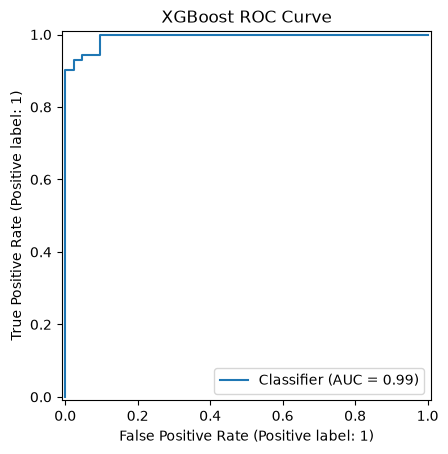

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("XGBoost ROC Curve")
plt.show()

Predicting an Individual Sample

In [29]:
print(X_test[0])
print(y_test[0])

[1.955e+01 2.877e+01 1.336e+02 1.207e+03 9.260e-02 2.063e-01 1.784e-01
 1.144e-01 1.893e-01 6.232e-02 8.426e-01 1.199e+00 7.158e+00 1.064e+02
 6.356e-03 4.765e-02 3.863e-02 1.519e-02 1.936e-02 5.252e-03 2.505e+01
 3.627e+01 1.786e+02 1.926e+03 1.281e-01 5.329e-01 4.251e-01 1.941e-01
 2.818e-01 1.005e-01]
0


In [ ]:
sample = X_test[0].reshape(1, -1)  #XGBoost expects 2D input and X_test[0] is 1D so reshaping is necessary

In [27]:
prediction = model.predict(sample)

print(prediction)

[0]


So correct prediction

Get Individual Prediction Probability

In [30]:
probability = model.predict_proba(sample)

print(probability)

[[0.9985598  0.00144025]]


In [31]:
print("Class 0 probability:", probability[0][0])
print("Class 1 probability:", probability[0][1])

Class 0 probability: 0.9985598
Class 1 probability: 0.0014402528


MOre XGBOOST Parameters

In [32]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    subsample=0.8,  # Use about 80% of observations per boosting round.
    colsample_bytree=0.8, # Use about 80% of features per tree.
    gamma=0,  # No additional minimum split penalty.
    reg_alpha=0,  # No L1 regularization.
    reg_lambda=1, # use l2 regularization
    objective="binary:logistic",
    eval_metric="logloss",  # Use log loss for evaluation.
    random_state=42
)

Adding a Validation Set

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [34]:
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Early Stopping : XGBoost can stop when validation performance hasn't improved for 50 rounds.

In [35]:
print(model.best_iteration)

206


In [36]:
print(model.best_iteration)

206


Cross-Validation Implentation

In [37]:
from sklearn.model_selection import cross_val_score

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV score:", scores.mean())

CV scores: [0.95614035 0.94736842 0.99122807 0.96491228 0.97345133]
Mean CV score: 0.9666200900481291


Hyperparameter Tuning

In [38]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [39]:
grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

In [40]:
print(grid.best_params_)
print(grid.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
0.9780821917808218


In [41]:
best_model = grid.best_estimator_

Feature Importance 

In [43]:
importance = best_model.feature_importances_

print(importance)

[1.1746585e-02 2.5980759e-02 1.0176354e-02 1.7483668e-02 6.5148273e-03
 1.8587440e-02 2.3120115e-02 3.1217474e-02 5.3060721e-03 7.1661607e-03
 7.8600300e-03 6.9787605e-03 4.3048523e-03 1.8091295e-02 3.1700304e-03
 6.0071438e-03 1.2817404e-02 1.9513967e-05 4.4011511e-03 1.9458724e-02
 1.7465833e-01 1.5863046e-02 2.2009240e-01 2.1903330e-02 1.5499972e-02
 1.1102249e-01 1.5410259e-02 1.7298414e-01 6.5552774e-03 5.6024450e-03]


In [45]:
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
22          worst perimeter    0.220092
20             worst radius    0.174658
27     worst concave points    0.172984
25        worst compactness    0.111022
7       mean concave points    0.031217
1              mean texture    0.025981
6            mean concavity    0.023120
23               worst area    0.021903
19  fractal dimension error    0.019459
5          mean compactness    0.018587
13               area error    0.018091
3                 mean area    0.017484
21            worst texture    0.015863
24         worst smoothness    0.015500
26          worst concavity    0.015410
16          concavity error    0.012817
0               mean radius    0.011747
2            mean perimeter    0.010176
10             radius error    0.007860
9    mean fractal dimension    0.007166
11            texture error    0.006979
28           worst symmetry    0.006555
4           mean smoothness    0.006515
15        compactness error    0.006007


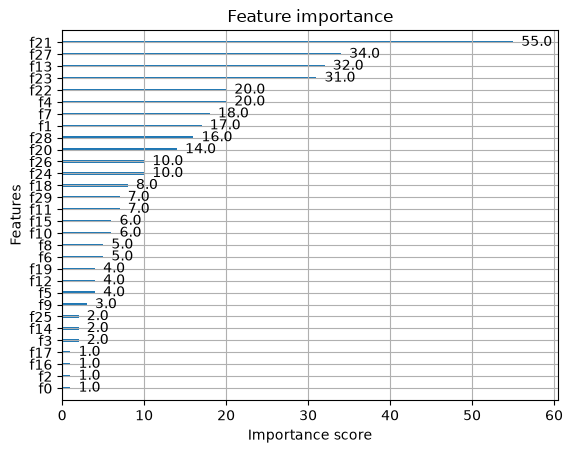

In [47]:
from xgboost import plot_importance

plot_importance(best_model)

plt.show()